In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN, MeanShift, estimate_bandwidth
from sklearn.decomposition import PCA
#pca برای حذف فیوچر ها و کم تر کردن ابعاد
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
plt.rcParams['figure.figsize']=(8,6)

In [8]:
df=pd.read_csv(r"C:\Users\Student\Desktop\unsupervised_dataset_1000x20.csv")
print(df.head())
print(df.shape)

   taxpayer_id  annual_income  declared_expenses  tax_paid  num_dependents  \
0     1.440500       0.507025          -0.098593 -1.034833        0.232171   
1     0.133728      -1.087384          -0.683022 -0.093363        1.920673   
2     1.177965      -0.225835           0.060271 -1.222296       -0.124959   
3    -1.356662       0.278508          -1.312332  1.512633       -0.170030   
4    -1.141540       0.210362          -1.182621  1.534337       -1.342959   

   business_transactions  late_payments  audit_score  property_count  \
0              -0.781695       2.522289    -0.178228        1.097592   
1               1.744628      -0.714245    -0.656819        0.349981   
2              -0.971904       0.910496    -0.437806        1.455680   
3               0.959593      -0.236286    -0.797876        0.018365   
4               0.527744       0.078162    -1.453508       -0.226619   

   vehicle_count  foreign_transfer  digit_transactions_ratio  \
0      -0.140452         -1.353934

In [10]:
#remove duplicates
df=df.drop_duplicates()

#handle missing values
imputer=SimpleImputer(strategy='mean')
df_imputed=pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

#separate features
#standardize
scaler=StandardScaler()
X_scaled=scaler.fit_transform(df_imputed)

print("Cleaned Data Shape:", X_scaled.shape)

Cleaned Data Shape: (1000, 20)


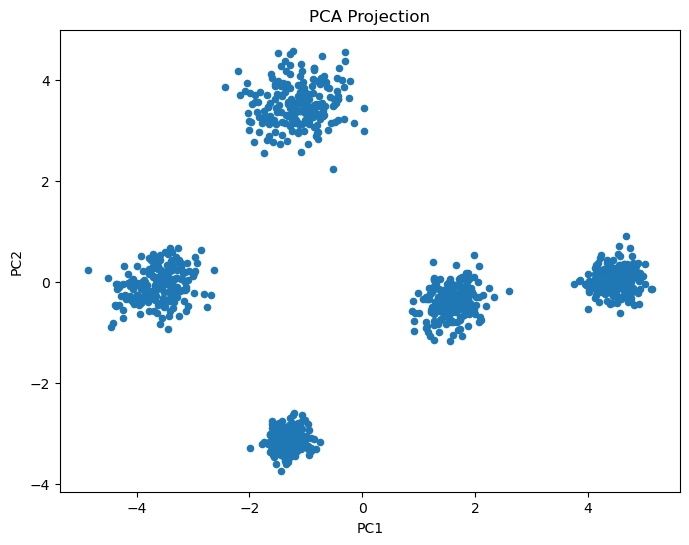

In [12]:
#pca ویژگی های مهم رو فقط حفظ میکنه
pca=PCA(n_components=2)
X_pca=pca.fit_transform(X_scaled)
plt.scatter(X_pca[:,0], X_pca[:,1], s=20)
plt.title("PCA Projection")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

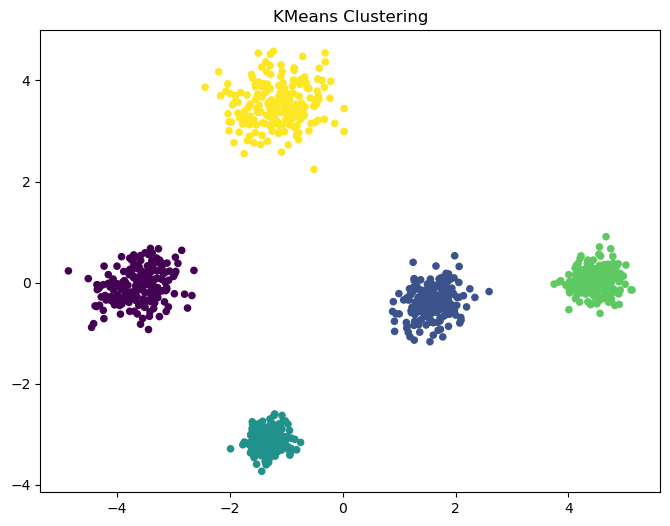

Silhouette Score 0.6570377615437236


In [15]:
kmeans=KMeans(n_clusters=5, random_state=42)
labels=kmeans.fit_predict(X_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap='viridis', s=20)
plt.title("KMeans Clustering")
plt.show()

score=silhouette_score(X_scaled, labels)
print("Silhouette Score", score)

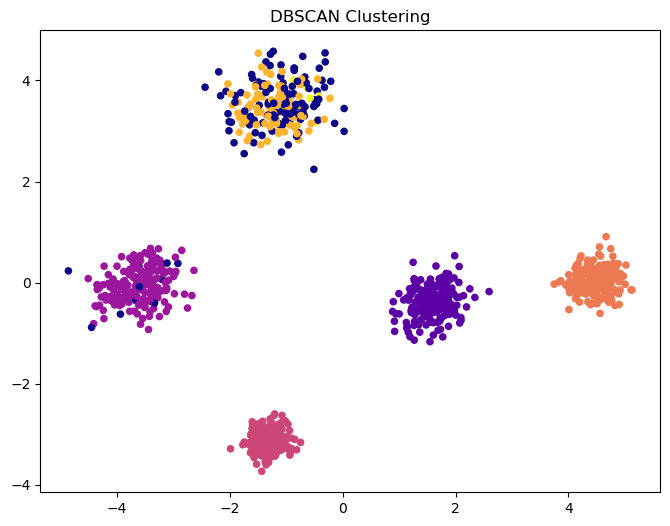

Silhouette Score: 0.5252193378233654


In [16]:
dbscan=DBSCAN(eps=1.8, min_samples=5)
labels=dbscan.fit_predict(X_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap='plasma', s=20)
plt.title("DBSCAN Clustering")
plt.show()

if len(set(labels)) > 1:
    score=silhouette_score(X_scaled, labels)
    print("Silhouette Score:", score)

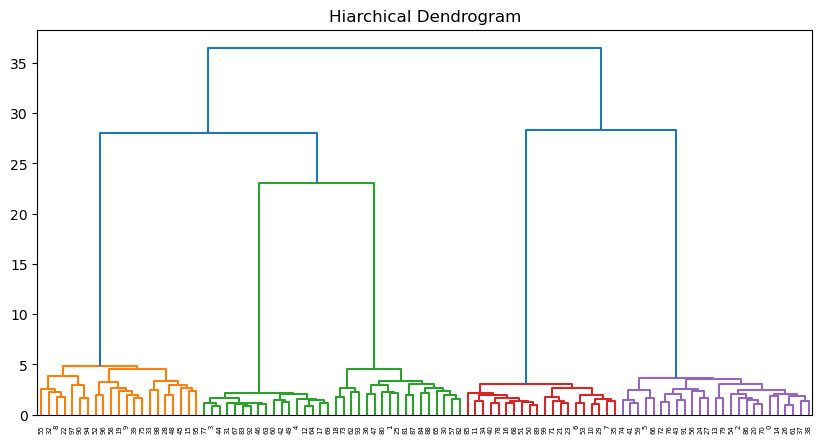

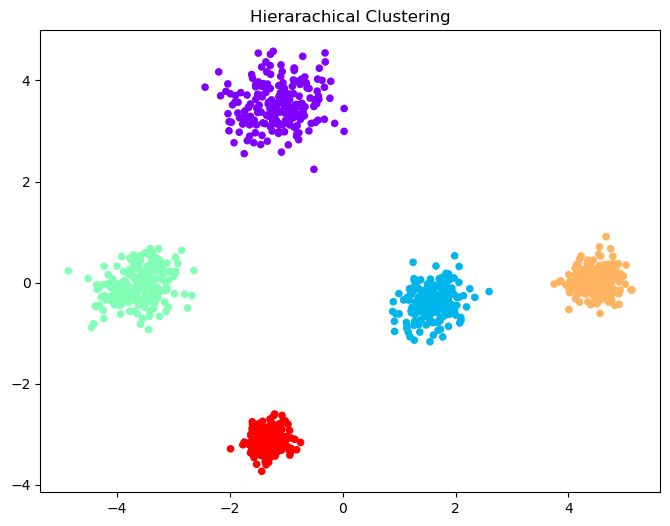

Silhouette Score: 0.6570377615437236


In [21]:
#hiearchical clustering

linekd = linkage(X_scaled[:100], method='ward')
plt.figure(figsize=(10,5))
dendrogram(linekd)
plt.title("Hiarchical Dendrogram")
plt.show()

hiearchical=AgglomerativeClustering(n_clusters=5)
labels=hiearchical.fit_predict(X_scaled)

plt.scatter(X_pca[:,0],X_pca[:,1],c=labels,cmap='rainbow',s=20)
plt.title("Hierarachical Clustering")
plt.show()

score=silhouette_score(X_scaled, labels)
print("Silhouette Score:", score)

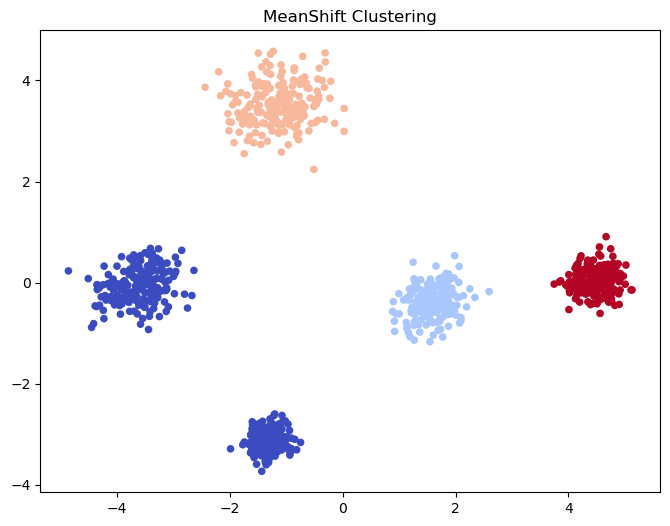

silhouette score: 0.5497042203607252


In [24]:
#Meanshift

bandwidth=estimate_bandwidth(X_scaled, quantile=0.2,n_samples=500)

meanshift=MeanShift(bandwidth=bandwidth)
labels=meanshift.fit_predict(X_scaled)

plt.scatter(X_pca[:,0],X_pca[:,1], c=labels,cmap='coolwarm',s=20)
plt.title("MeanShift Clustering")
plt.show()

if len(set(labels)) > 1:
    score=silhouette_score(X_scaled, labels)
    print("silhouette score:",score)

In [ ]:
#کدای آخر فایل که زیاد بود نزدم.png 
#بقیش آخرش از اینجاس
#پروژه نمونه هور هم ببینم
#با ریکوئستم میشه رفت دیتا گرفت از سایتا